In [36]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import time

_ROOT = os.path.abspath(os.path.join(os.path.dirname(__file__) if "__file__" in dir() else os.getcwd(), ".."))
if _ROOT not in sys.path:
    sys.path.insert(0, _ROOT)

from lqr import solve_and_execute_lqr

## Given-Weight Tracking (Risk-Parity-Style): Setup and Initialization

**Goal**: choose trades $u_t$ over $t=0,\ldots,T-1$ to minimize a finite-horizon objective with linear dynamics
$$s_{t+1}=A s_t + B u_t,$$
where the portfolio is encouraged to track a static target weight (soft constraint at the terminal time).

This notebook now uses the same modeling idea as `Risk_Parity_test.py`: a static target (`w_given`, analogous to `w_RP`) plus trade-penalty tracking.

**Required model inputs**

| Item | Meaning |
|------|---------|
| $T$ | Number of time steps |
| $w_0$ | Initial weight |
| $w_{\mathrm{given}}$ | Static target weight to track |
| $\kappa$ | Running tracking penalty strength |
| $\gamma_{tc}$ | Trading-cost penalty strength |
| $k_{\mathrm{terminal}}$ | Terminal tracking penalty strength |

**Augmented-state LQR construction (same structure as risk-parity tracking)**

1. Use augmented state $S_t=[w_t,1]$ and control $u_t=\Delta w_t$ with dynamics $w_{t+1}=w_t+u_t$.
2. Encode the running cost
$$\frac{\kappa}{2}(w_{t+1}-w_{\mathrm{given}})^2+\frac{\gamma_{tc}}{2}u_t^2$$
into LQR matrices $(Q,R,M)$.
3. Encode terminal cost
$$\frac{k_{\mathrm{terminal}}}{2}(w_T-w_{\mathrm{given}})^2$$
into $P_T$.
4. Solve and roll out directly with `result = solve_and_execute_lqr(..., P_terminal=P_T)`.

This gives a DP/LQR path directly comparable to the CVXPY formulation below.

## Optional parameter toggles (current given-weight model)

| Parameter | Set to | Effect |
|-----------|--------|--------|
| **`k_terminal`** | `0` | Removes terminal soft anchoring to `w_given`; only running tracking/trade costs remain. |
| **`kappa_ex`** | `0` | Removes running tracking pressure toward `w_given`; only trade regularization (and optional terminal term) remains. |
| **`gamma_tc_ex`** | `0` | Removes trade penalty; model may trade aggressively to match the target quickly. |

**Practical note:** for stable and realistic trajectories, keep at least one of `kappa_ex` or `gamma_tc_ex` positive, and usually keep `k_terminal > 0` when a strict end-horizon target is desired.

In [37]:
# Given-weight tracking parameters (same structure as Risk_Parity_test.py,
# where w_given here plays the same role as w_RP there)
T_ex = 30
w0_ex = 0.0
w_given_ex = 0.25

kappa_ex = 0.04      # running tracking penalty strength
gamma_tc_ex = 0.10   # transaction cost strength
k_terminal = 80.0    # terminal tracking penalty strength

# Augmented state S_t = [w_t, 1], control u_t = Δw_t
A_ex = np.eye(2)
B_ex = np.array([[1.0], [0.0]])

Q_ex = np.array([
    [0.5 * kappa_ex, -0.5 * kappa_ex * w_given_ex],
    [-0.5 * kappa_ex * w_given_ex, 0.5 * kappa_ex * (w_given_ex ** 2)],
])
R_ex = np.array([[0.5 * (kappa_ex + gamma_tc_ex)]])
M_ex = np.array([
    [0.5 * kappa_ex],
    [-0.5 * kappa_ex * w_given_ex],
])

# Terminal quadratic form for 0.5 * k_terminal * (w_T - w_given)^2
P_T_ex = np.array([
    [0.5 * k_terminal, -0.5 * k_terminal * w_given_ex],
    [-0.5 * k_terminal * w_given_ex, 0.5 * k_terminal * (w_given_ex ** 2)],
])

s0_ex = np.array([w0_ex, 1.0])

print(
    f"T={T_ex}, w0={w0_ex}, w_given={w_given_ex}, "
    f"kappa={kappa_ex}, gamma_tc={gamma_tc_ex}, k_terminal={k_terminal}"
)


T=30, w0=0.0, w_given=0.25, kappa=0.04, gamma_tc=0.1, k_terminal=80.0


In [38]:
# ════════════════════════════════════════════════════════
#  DP / LQR (implemented with solver.py functions)
# ════════════════════════════════════════════════════════
t0 = time.perf_counter()
result_ex = solve_and_execute_lqr(
    T_ex, A_ex, B_ex, Q_ex, R_ex, M_ex, s0_ex, P_terminal=P_T_ex
)
print(f"solve+execute: {(time.perf_counter() - t0) * 1000:.2f} ms")

w_path = result_ex.s_path[:, 0]
print(f"|w_T - w_given| (DP) = {abs(w_path[-1] - w_given_ex):.6f}")

solve+execute: 2.15 ms
|w_T - w_given| (DP) = 0.000000


CVXPY solve: 234.84 ms, status=optimal
|w_T - w_given| (CVXPY) = 0.000000


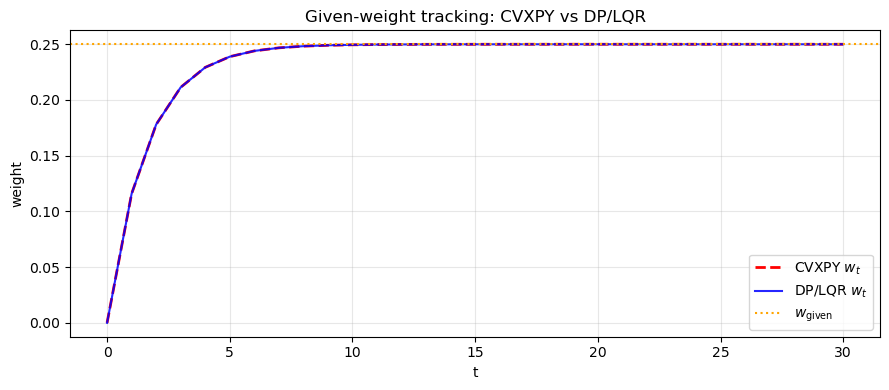

max |w_LQR - w_CVX| = 2.78e-17


In [39]:
# CVXPY formulation following Risk_Parity_test.py (same objective as DP above)
import cvxpy as cp

W = cp.Variable(T_ex + 1)
U = cp.Variable(T_ex)

constraints = [W[0] == w0_ex]
for t in range(T_ex):
    constraints.append(W[t + 1] == W[t] + U[t])

cost_cvx = 0
for t in range(T_ex):
    cost_cvx += 0.5 * kappa_ex * cp.square(W[t + 1] - w_given_ex)
    cost_cvx += 0.5 * gamma_tc_ex * cp.square(U[t])
cost_cvx += 0.5 * k_terminal * cp.square(W[T_ex] - w_given_ex)

prob_cvx = cp.Problem(cp.Minimize(cost_cvx), constraints)
t0 = time.perf_counter()
prob_cvx.solve(solver=cp.OSQP, verbose=False)
print(f"CVXPY solve: {(time.perf_counter() - t0) * 1000:.2f} ms, status={prob_cvx.status}")

w_cvx = np.asarray(W.value)
print(f"|w_T - w_given| (CVXPY) = {abs(w_cvx[-1] - w_given_ex):.6f}")

fig_c, ax_c = plt.subplots(figsize=(9, 4))
t_steps = np.arange(T_ex + 1)
ax_c.plot(t_steps, w_cvx, "r--", lw=2, label="CVXPY $w_t$")
ax_c.plot(t_steps, w_path, "b-", lw=1.5, alpha=0.85, label="DP/LQR $w_t$")
ax_c.axhline(w_given_ex, color="orange", ls=":", lw=1.5, label=r"$w_{\mathrm{given}}$")
ax_c.set_xlabel("t")
ax_c.set_ylabel("weight")
ax_c.set_title("Given-weight tracking: CVXPY vs DP/LQR")
ax_c.legend()
ax_c.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"max |w_LQR - w_CVX| = {np.max(np.abs(w_path - w_cvx)):.2e}")


## Multi-Asset extension for a given target-weight vector (DP via `solver.py`)


w_given_vec: [0.3  0.2  0.15 0.25 0.1 ]
w0_vec    : [0. 0. 1. 0. 0.] (sum= 1.0 )
multi-asset DP solve+execute: 3.23 ms
n_assets=5, ||w_T - w_given||_2 = 6.938894e-17


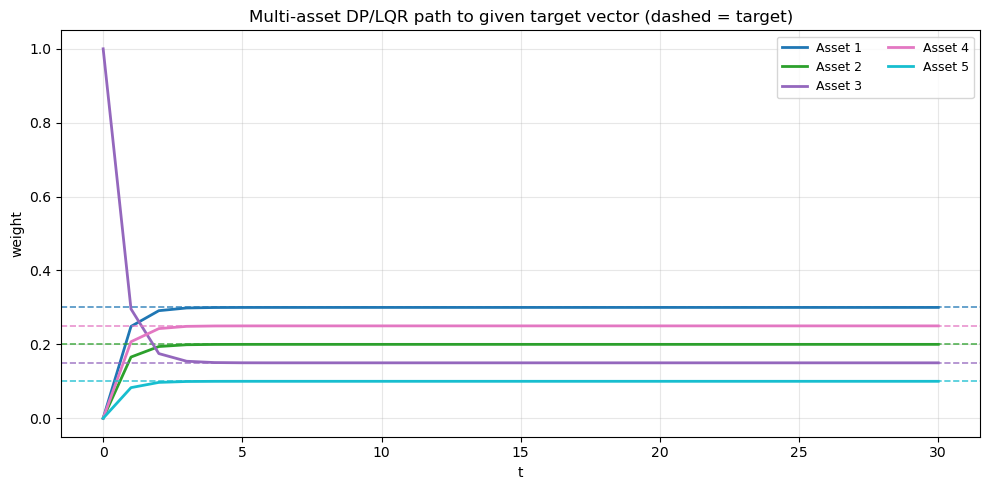

In [40]:
# Multi-asset given-weight tracking (DP/LQR)
import cvxpy as cp

def build_multiasset_tracking_lqr_matrices(w_target, kappa, gamma_tc, k_terminal):
    """Same matrix structure as Risk_Parity_test.py, with terminal anchoring."""
    n = len(w_target)
    na = n + 1

    A_aug = np.eye(na)
    B_aug = np.vstack([np.eye(n), np.zeros((1, n))])

    # Running cost: 0.5*kappa*||w_{t+1}-w_target||^2 + 0.5*gamma_tc*||u_t||^2
    Q_aug = np.zeros((na, na))
    Q_aug[:n, :n] = 0.5 * kappa * np.eye(n)
    Q_aug[n, :n] = -0.5 * kappa * w_target
    Q_aug[:n, n] = -0.5 * kappa * w_target
    Q_aug[n, n] = 0.5 * kappa * float(w_target @ w_target)

    R_mat = 0.5 * (kappa + gamma_tc) * np.eye(n)

    M_aug = np.zeros((na, n))
    M_aug[:n, :] = 0.5 * kappa * np.eye(n)
    M_aug[n, :] = -0.5 * kappa * w_target

    # Terminal cost: 0.5*k_terminal*||w_T - w_target||^2
    P_T = np.zeros((na, na))
    P_T[:n, :n] = 0.5 * k_terminal * np.eye(n)
    P_T[n, :n] = -0.5 * k_terminal * w_target
    P_T[:n, n] = -0.5 * k_terminal * w_target
    P_T[n, n] = 0.5 * k_terminal * float(w_target @ w_target)

    return A_aug, B_aug, Q_aug, R_mat, M_aug, P_T



# Example: 5 assets
n_assets = 5
T_ma = 30
kappa_ma = 2.0
gamma_tc_ma = 0.5
k_terminal_ma = 80.0

w_given_vec = np.array([0.30, 0.20, 0.15, 0.25, 0.10])


w0_vec = np.array([0.00, 0.0, +1.0,0.0, 0.0])
print("w_given_vec:", np.round(w_given_vec, 4))
print("w0_vec    :", np.round(w0_vec, 4), "(sum=", np.round(w0_vec.sum(), 6), ")")

A_ma, B_ma, Q_ma, R_ma, M_ma, P_T_ma = build_multiasset_tracking_lqr_matrices(
    w_given_vec, kappa_ma, gamma_tc_ma, k_terminal_ma
)

s0_ma = np.append(w0_vec, 1.0)

t0 = time.perf_counter()
result_ma = solve_and_execute_lqr(
    T_ma, A_ma, B_ma, Q_ma, R_ma, M_ma, s0_ma, P_terminal=P_T_ma
)
print(f"multi-asset DP solve+execute: {(time.perf_counter() - t0) * 1000:.2f} ms")

W_path_ma = result_ma.s_path[:, :n_assets]
err_ma = np.linalg.norm(W_path_ma - w_given_vec, axis=1)
print(f"n_assets={n_assets}, ||w_T - w_given||_2 = {err_ma[-1]:.6e}")

# Plot 1: per-asset paths vs targets
fig_ma, ax_ma = plt.subplots(figsize=(10, 5))
t_steps_ma = np.arange(T_ma + 1)
colors = plt.cm.tab10(np.linspace(0, 0.9, n_assets))

for i in range(n_assets):
    ax_ma.plot(t_steps_ma, W_path_ma[:, i], color=colors[i], lw=2, label=f"Asset {i+1}")
    ax_ma.axhline(w_given_vec[i], color=colors[i], ls="--", lw=1.2, alpha=0.8)

ax_ma.set_xlabel("t")
ax_ma.set_ylabel("weight")
ax_ma.set_title("Multi-asset DP/LQR path to given target vector (dashed = target)")
ax_ma.legend(ncol=2, fontsize=9)
ax_ma.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


multi-asset CVXPY solve: 182.58 ms, status=optimal
n_assets=5, ||w_T - w_given||_2 (CVXPY) = 0.000000e+00
max ||W_DP - W_CVX||_inf = 5.00e-16


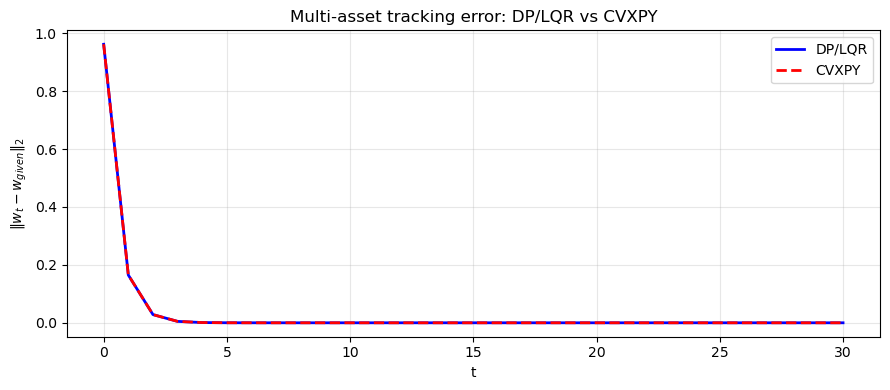

In [41]:
# Multi-asset CVXPY benchmark (same objective as the DP/LQR block above)
W_ma = cp.Variable((T_ma + 1, n_assets))
U_ma = cp.Variable((T_ma, n_assets))

constraints_ma = [W_ma[0] == w0_vec]
for t in range(T_ma):
    constraints_ma.append(W_ma[t + 1] == W_ma[t] + U_ma[t])

cost_ma = 0
for t in range(T_ma):
    cost_ma += 0.5 * kappa_ma * cp.sum_squares(W_ma[t + 1] - w_given_vec)
    cost_ma += 0.5 * gamma_tc_ma * cp.sum_squares(U_ma[t])
cost_ma += 0.5 * k_terminal_ma * cp.sum_squares(W_ma[T_ma] - w_given_vec)

prob_ma = cp.Problem(cp.Minimize(cost_ma), constraints_ma)
t0 = time.perf_counter()
prob_ma.solve(solver=cp.OSQP, verbose=False)
print(f"multi-asset CVXPY solve: {(time.perf_counter() - t0) * 1000:.2f} ms, status={prob_ma.status}")

W_cvx_ma = np.asarray(W_ma.value)
err_cvx_ma = np.linalg.norm(W_cvx_ma - w_given_vec, axis=1)

print(f"n_assets={n_assets}, ||w_T - w_given||_2 (CVXPY) = {err_cvx_ma[-1]:.6e}")
print(f"max ||W_DP - W_CVX||_inf = {np.max(np.abs(W_path_ma - W_cvx_ma)):.2e}")

# Compare tracking-error trajectories
fig_cmp, ax_cmp = plt.subplots(figsize=(9, 4))
ax_cmp.plot(t_steps_ma, err_ma, "b-", lw=2, label="DP/LQR")
ax_cmp.plot(t_steps_ma, err_cvx_ma, "r--", lw=2, label="CVXPY")
ax_cmp.set_xlabel("t")
ax_cmp.set_ylabel(r"$\|w_t - w_{given}\|_2$")
ax_cmp.set_title("Multi-asset tracking error: DP/LQR vs CVXPY")
ax_cmp.legend()
ax_cmp.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()